In [1]:
import pandas as pd

In [2]:
stressLvlDf = pd.read_csv("../data/raw/StressLevelDataset.csv")
train_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv')
test_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv')

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [5]:
feature_cols = [c for c in train_df.columns if c != "target"]
X = train_df[feature_cols]
y = train_df["target"]

print(f"PCA on {len(feature_cols)} features")

PCA on 24 features


In [6]:
#PCA 

pca_full = PCA()
pca_full.fit(X)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [ ]:
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

In [13]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["target"] = train_df["target"].values

pca_target_corr = pca_df.corr()["target"].drop("target")
print(pca_target_corr)

PC1    0.886610
PC2   -0.050625
Name: target, dtype: float64


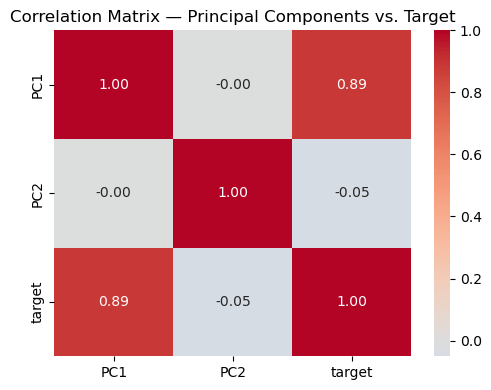

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(pca_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Matrix — Principal Components vs. Target")
plt.tight_layout()
plt.show()

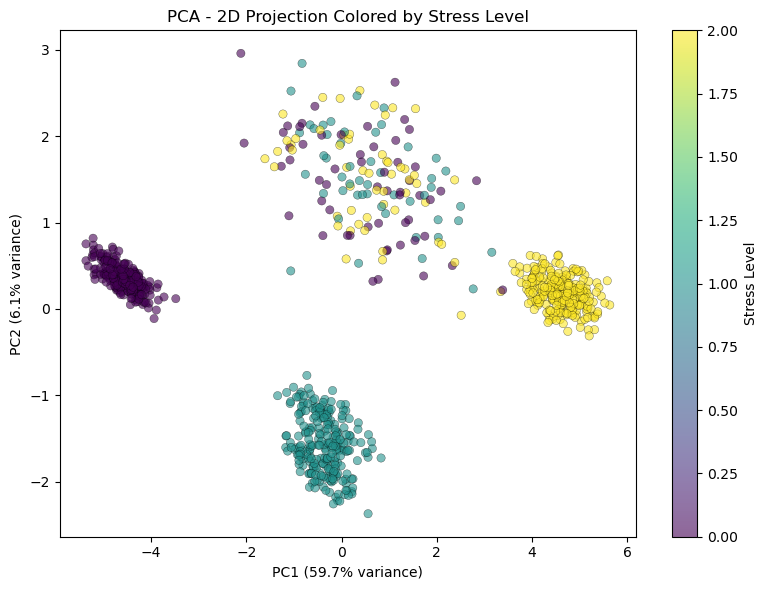

Total variance captured by 2 components: 65.7%


In [28]:

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.3)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA - 2D Projection Colored by Stress Level")
plt.colorbar(scatter, label="Stress Level")
plt.tight_layout()
plt.show()

print(f"Total variance captured by 2 components: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

In [10]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

print("Top contributors to PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\nTop contributors to PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

Top contributors to PC1:
future_career_concerns    0.247207
anxiety_level             0.245885
bullying                  0.243752
self_esteem               0.241313
depression                0.241062
Name: PC1, dtype: float64

Top contributors to PC2:
blood_pressure       0.734896
social_support       0.477569
breathing_problem    0.253409
physical_score       0.157597
social_score         0.154995
Name: PC2, dtype: float64


In [18]:
print(loadings["PC1"].abs().sort_values(ascending=False))

future_career_concerns          0.247207
anxiety_level                   0.245885
bullying                        0.243752
self_esteem                     0.241313
depression                      0.241062
sleep_quality                   0.239158
teacher_student_relationship    0.235488
headache                        0.228446
safety                          0.228262
academic_performance            0.227238
peer_pressure                   0.225813
basic_needs                     0.225802
extracurricular_activities      0.225532
social_support                  0.218091
noise_level                     0.207683
study_load                      0.201500
living_conditions               0.199831
breathing_problem               0.190417
blood_pressure                  0.146095
social_score                    0.119252
environment_score               0.111553
mental_health_history           0.106595
mental_health_score             0.088057
physical_score                  0.081450
Name: PC1, dtype

In [ ]:
#All the features in PAC1 including feature enginered ones there for doing on raw dataset 

In [19]:
train_df_r = pd.read_csv('../results/outputs/Splits Stress_level_dataset/stress_level_train_scaled.csv')
test_df_r = pd.read_csv('../results/outputs/Splits Stress_level_dataset/stress_level_test_scaled.csv')

In [37]:
raw_feature_cols = [c for c in train_df_r.columns if c != "target"]

X_train_raw = train_df_r[raw_feature_cols]
X_test_raw = test_df_r[raw_feature_cols]

y_train_r = train_df_r["target"]
y_test_r = test_df_r["target"]

print(f"PCA on {len(raw_feature_cols)} features")

pca_clean = PCA(n_components=2)
X_train_pca_clean = pca_clean.fit_transform(X_train_raw)
X_test_pca_clean = pca_clean.transform(X_test_raw)

loadings_clean = pd.DataFrame(pca_clean.components_.T, columns=["PC1", "PC2"], index=raw_feature_cols)
print(loadings_clean["PC1"].abs().sort_values(ascending=False))

PCA on 20 features
future_career_concerns          0.252397
anxiety_level                   0.250874
bullying                        0.248217
self_esteem                     0.247400
depression                      0.246009
sleep_quality                   0.244937
teacher_student_relationship    0.241062
headache                        0.232865
safety                          0.232821
academic_performance            0.232286
basic_needs                     0.230294
peer_pressure                   0.229619
extracurricular_activities      0.229449
social_support                  0.224218
noise_level                     0.213328
study_load                      0.205976
living_conditions               0.202805
breathing_problem               0.193465
blood_pressure                  0.150179
mental_health_history           0.108610
Name: PC1, dtype: float64


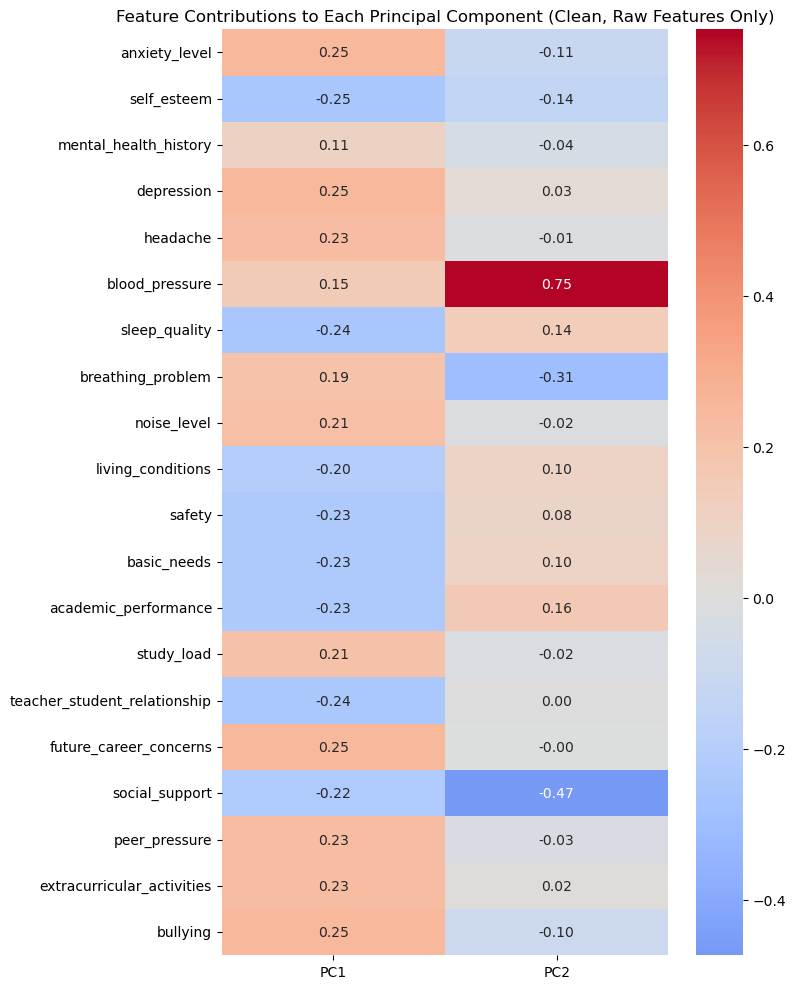

In [39]:
plt.figure(figsize=(8, 10))
sns.heatmap(loadings_clean, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Feature Contributions to Each Principal Component (Clean, Raw Features Only)")
plt.tight_layout()
plt.show()

PC1    0.886610
PC2   -0.050625
Name: target, dtype: float64


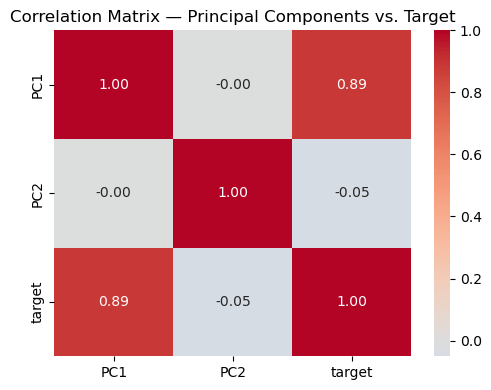

In [40]:
pca_df_r = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df_r["target"] = train_df_r["target"].values

pca_target_corr = pca_df_r.corr()["target"].drop("target")
print(pca_target_corr)

plt.figure(figsize=(5, 4))
sns.heatmap(pca_df_r.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Matrix — Principal Components vs. Target")
plt.tight_layout()
plt.show()

In [42]:
pca_train_export = pd.DataFrame(X_train_pca_clean, columns=["PC1", "PC2"])
pca_train_export["target"] = y_train_r.values

pca_test_export = pd.DataFrame(X_test_pca_clean, columns=["PC1", "PC2"])
pca_test_export["target"] = y_test_r.values

pca_train_export.to_csv("../results/outputs/PCA/pca_train.csv", index=False)
pca_test_export.to_csv("../results/outputs/PCA/pca_test.csv", index=False)

print("Saved pca_train.csv:", pca_train_export.shape)
print("Saved pca_test.csv:", pca_test_export.shape)

Saved pca_train.csv: (880, 3)
Saved pca_test.csv: (220, 3)


In [43]:
import joblib
joblib.dump(pca_clean, "../results/model_trained_files/pca_model.pkl")

['../results/model_trained_files/pca_model.pkl']